# 6.2.4  属性

# 属性是一种特殊形式的成员方法，结合了公开数据成员和成员方法的优点，既可以像成员方法那样进行必要的检查，又可以像数据成员一样灵活地访问。

# 公开数据成员：和封装特性违背

# 私有成员：访问需要调用成员方法，不够方便

# 1. 只读属性

In [1]:
class Test:
    def __init__(self, value):
        self.__value = value

    @property  # 修饰器，定义属性，提供对私有数据成员的访问
    def value(self):               #只读属性，无法修改和删除
        return self.__value

In [2]:
t = Test(3)
t.value

3

In [3]:
t.value = 5

AttributeError: can't set attribute

In [4]:
del t.value

AttributeError: can't delete attribute

# 2. 可读、可写属性


In [1]:
class Test:
    def __init__(self, value):
        self.__value = value

    def __get(self): #读取私有数据成员的值
        return self.__value

    def __set(self, v): 
        self.__value = v#修改私有数据成员的值
        
    #value 是一个 property（属性），
    #它通过 property(__get, __set) 将 __get 和 __set 方法绑定到 value 上
    
    value = property(__get, __set)#可读可写属性

    def show(self):
        print(self.__value)

In [7]:
t = Test(3)
t.value 

3

In [9]:
#t._Test__value

In [10]:
t.value  = 5
t.show()

5


In [11]:
del t.value

AttributeError: can't delete attribute

# 3. 可读、可修改、可删除的属性。


In [2]:
 class Test:
    def __init__(self, value):
        self.__value = value

    def __get(self):
        return self.__value

    def __set(self, v):
        self.__value = v

    def __del(self):
        del self.__value

    value = property(__get, __set, __del)#可读、可写、可删除的属性

    def show(self):
        print(self.__value)


In [3]:
t = Test(3)
t.show()

3


In [4]:
t.value

3

In [5]:
t.value = 5

In [6]:
t.show() #属性对应的私有变量也得到了相应的修改

5


In [18]:
del t.value #删除属性
        #对应的私有数据成员已删除

AttributeError: _Test__value

In [19]:
t.value 

AttributeError: 'Test' object has no attribute '_Test__value'

In [20]:
t.value = 1            #为对象动态增加属性和对应的私有数据成员
t.show()

1


# 6.2.5  类与对象的动态性、混入机制


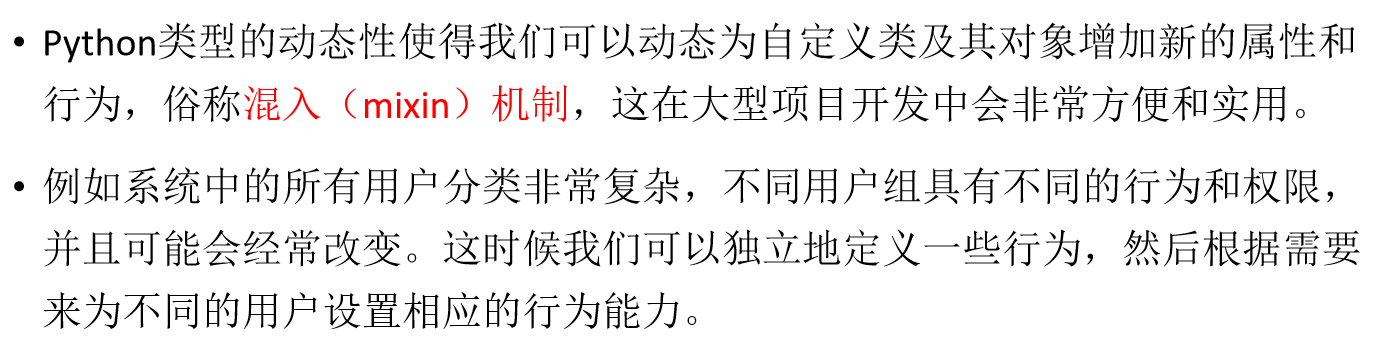

In [8]:
import types
class Person(object):
    def __init__(self, name):
        assert isinstance(name, str), 'name must be string'
        self.name = name
        
def sing(self):
    print(self.name+' can sing.')

def walk(self):
    print(self.name+' can walk.')
    
def eat(self):
    print(self.name+' can eat.')
    
    
zhang = Person('zhang')
zhang.sing() 


AttributeError: 'Person' object has no attribute 'sing'

In [9]:
zhang.sing = types.MethodType(sing, zhang) #动态增加一个新行为
zhang.sing()


zhang can sing.


# 6.3  继承、多态

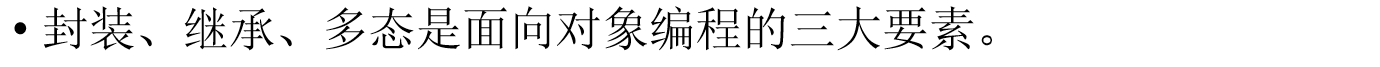

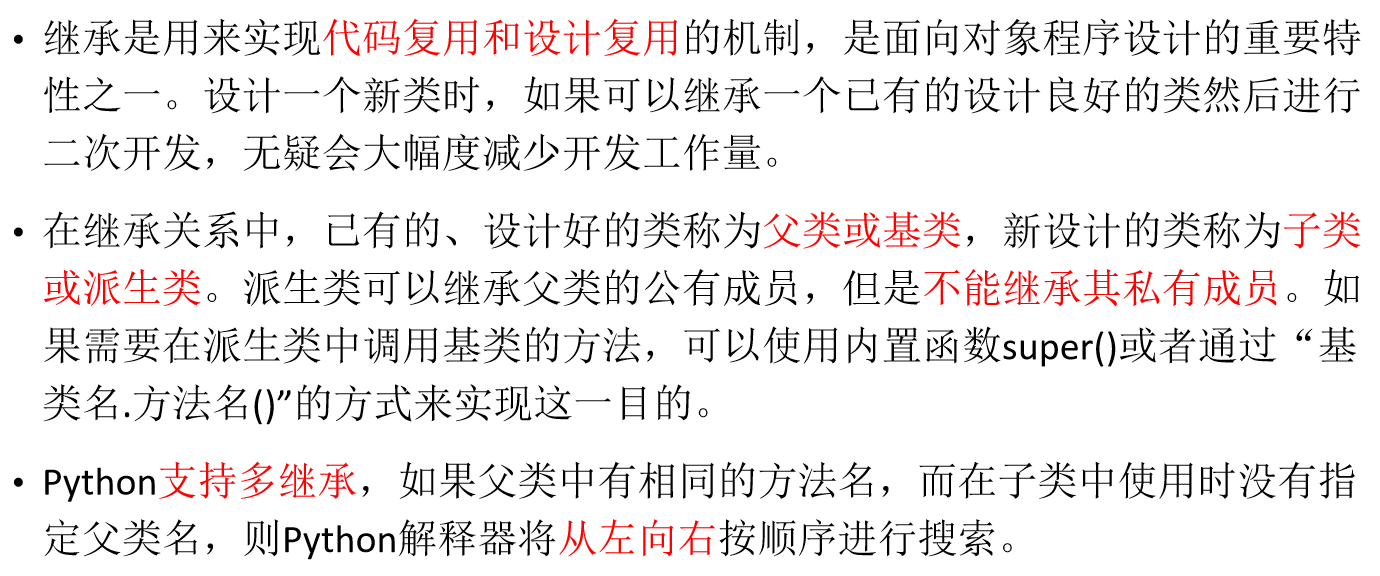

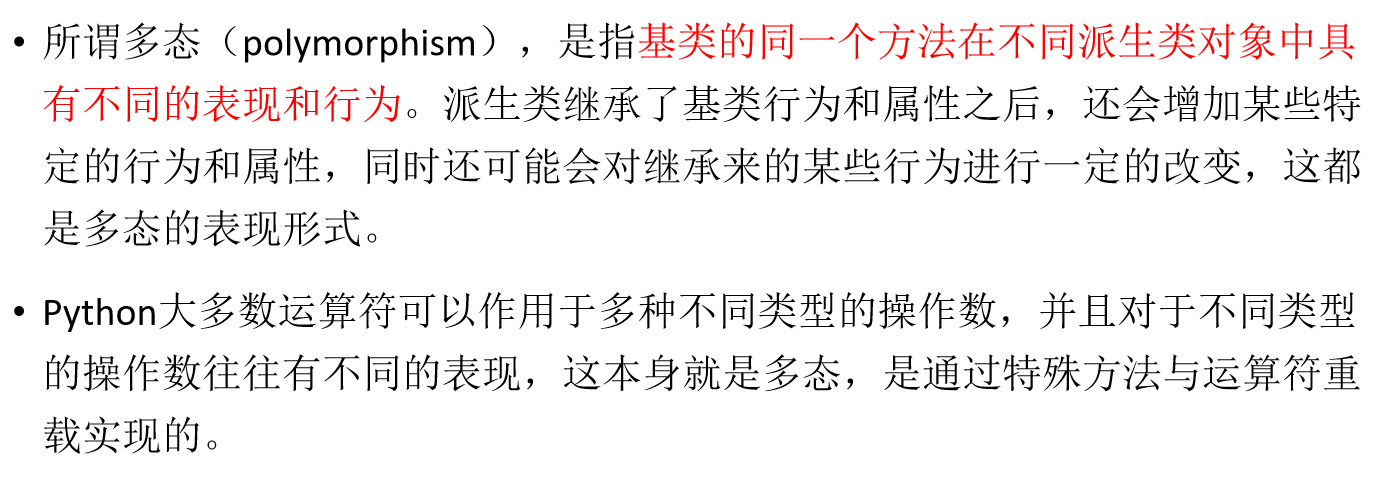

In [9]:
class Animal(object):      #定义基类
    def show(self):
        print('I am an animal.')
        
class Cat(Animal): #派生类，覆盖了基类的show()方法
    def show(self):
        print('I am a cat.')

class Dog(Animal):         #派生类
    def show(self):
        print('I am a dog.')
        
class Tiger(Animal):       #派生类
    def show(self):
        print('I am a tiger.')
        
class Test(Animal):        #派生类，没有覆盖基类的show()方法
    pass


In [11]:
cat1 = Cat()
cat1.show()

I am a cat.


In [17]:
x = [item() for item in (Animal, Cat, Dog, Tiger, Test)]
for item in x:        #遍历基类和派生类对象并调用show()方法
    item.show()


I am an animal.
I am a cat.
I am a dog.
I am a tiger.
I am an animal.


# 6.4  特殊方法与运算符重载(见ppt)


In [17]:
class Demo:
    def __init__(self):
        print('调用__init__方法')

    def func(self):
        print('这是一个普通的方法')

    def __del__(self):
        print('调用__del__方法')           
        
def create_demo():
    obj = Demo()  # 输出：调用__init__方法
    obj.func()    # 输出：这是一个普通的方法
    # 函数结束，obj 不再被引用，触发 __del__

create_demo()  

调用__init__方法
这是一个普通的方法
调用__del__方法


当g.func()执行后，对象g没有在任何一个地方被继续引用，这时Python的垃圾回收机制会主动回收这个对象，即销毁g，此时自动调用__del__方法.